# WEEK 4 of the Capstone Project


### STEP 0 - IMPORT RELEVANT PACKAGES


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import sys
sys.path.append('../..')  # Go up two levels to project root

import importlib
import data_utils
importlib.reload(data_utils)

# Import utility functions
from data_utils import (
    load_initial_data,
    load_week1_data,
    load_week2_data,
    load_week3_data,
    combine_data,
    plot_2d_scatter_with_distribution,
    plot_3d_scatter_with_distribution,
    plot_tsne_with_distribution,
    plot_bo_visualization_2d,
    plot_function_summary_subplot
)

TSNE_RANDOM_STATE = 42


### STEP 1 - DOWNLOAD THE INITIAL DATA


In [22]:
# Load initial data using utility function
base_dir = Path('/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/data/initial_data')
initial_data = load_initial_data(base_dir)

print(f"Loaded initial data for {len(initial_data)} functions")
for function_name, data in initial_data.items():
    print(f"  {function_name}: {data['inputs'].shape[0]} samples, {data['inputs'].shape[1]} dimensions")


Loaded initial data for 8 functions
  function_1: 10 samples, 2 dimensions
  function_2: 10 samples, 2 dimensions
  function_3: 15 samples, 3 dimensions
  function_4: 30 samples, 4 dimensions
  function_5: 20 samples, 4 dimensions
  function_6: 20 samples, 5 dimensions
  function_7: 30 samples, 6 dimensions
  function_8: 40 samples, 8 dimensions


### STEP 2 - DOWNLOAD THE WEEK 1 DATA


In [23]:
# Load week1 data using utility function
week1_dir = Path('/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/data/week1')
week1_data = load_week1_data(week1_dir)

print(f"Loaded week1 data for {len(week1_data)} functions")
for function_name, data in week1_data.items():
    print(f"  {function_name}: Input shape = {data['input'].shape}, Output = {data['output']}")


Loaded week1 data for 8 functions
  function_1: Input shape = (2,), Output = 2.6752879910742468e-09
  function_2: Input shape = (2,), Output = 0.42721035515778233
  function_3: Input shape = (3,), Output = -0.45300818056360315
  function_4: Input shape = (4,), Output = -25.81769735182645
  function_5: Input shape = (4,), Output = 4219.157963029058
  function_6: Input shape = (5,), Output = -2.6736180536592746
  function_7: Input shape = (6,), Output = 0.013680510023283559
  function_8: Input shape = (8,), Output = 6.0739207860211


### STEP 3 - DOWNLOAD THE WEEK 2 DATA


In [24]:
# Load week2 data using utility function (files store the latest line as the newest week)
week2_dir = Path('/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/data/week2')
week2_data = load_week2_data(week2_dir)

print(f"Loaded week2 data for {len(week2_data)} functions")
for function_name, data in week2_data.items():
    print(f"  {function_name}: Input shape = {data['input'].shape}, Output = {data['output']}")


Loaded week2 data for 8 functions
  function_1: Input shape = (2,), Output = 2.308810742126141e-248
  function_2: Input shape = (2,), Output = 0.09143573616583116
  function_3: Input shape = (3,), Output = -0.16648410423830667
  function_4: Input shape = (4,), Output = 0.07635232865804342
  function_5: Input shape = (4,), Output = 4139.609565498906
  function_6: Input shape = (5,), Output = -1.732308297257106
  function_7: Input shape = (6,), Output = 1.9964705720993239
  function_8: Input shape = (8,), Output = 9.8362097005135


### STEP 4 - DOWNLOAD THE WEEK 3 DATA


In [25]:
# Load week3 data using utility function (files store the latest line as the newest week)
week3_dir = Path('/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/data/week3')
week3_data = load_week3_data(week3_dir)

print(f"Loaded week3 data for {len(week3_data)} functions")
for function_name, data in week3_data.items():
    print(f"  {function_name}: Input shape = {data['input'].shape}, Output = {data['output']}")


Loaded week3 data for 8 functions
  function_1: Input shape = (2,), Output = 0.025559285339829783
  function_2: Input shape = (2,), Output = 0.3317119096486708
  function_3: Input shape = (3,), Output = -0.16364425027712573
  function_4: Input shape = (4,), Output = -2.443739075344467
  function_5: Input shape = (4,), Output = 4205.41112909808
  function_6: Input shape = (5,), Output = -1.2341261163607111
  function_7: Input shape = (6,), Output = 0.8888266866145418
  function_8: Input shape = (8,), Output = 9.9008337717904


### FUNCTION 1 - COMBINED DATA AND VISUALISATION


In [26]:
# Function 1 - Combine original data with week 1, week 2, and week 3 data
function_name = 'function_1'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']

# Get week 2 new input and output
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Get week 3 new input and output
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']

# Combine inputs: original + week 1 + week 2 + week 3
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1)
])

# Combine outputs: original + week 1 + week 2 + week 3
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output])
])

print("=" * 60)
print(f"FUNCTION 1 - COMBINED DATA (Week 1 + Week 2 + Week 3)")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nWeek 1 input: {week1_input}")
print(f"Week 2 input: {week2_input}")
print(f"Week 3 input: {week3_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nWeek 1 output: {week1_output}")
print(f"Week 2 output: {week2_output}")
print(f"Week 3 output: {week3_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 1 - COMBINED DATA (Week 1 + Week 2 + Week 3)

Original inputs shape: (10, 2)
Original inputs:
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]]

Week 1 input: [0.5 0.5]
Week 2 input: [0. 0.]
Week 3 input: [0.6 0.6]

Combined inputs shape: (13, 2)
Combined inputs:
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.5        0.5       ]
 [0.         0.        ]
 [0.6        0.6       ]]

------------------------------------------------------------

Original outputs shape: (10,)
Original outputs:
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2

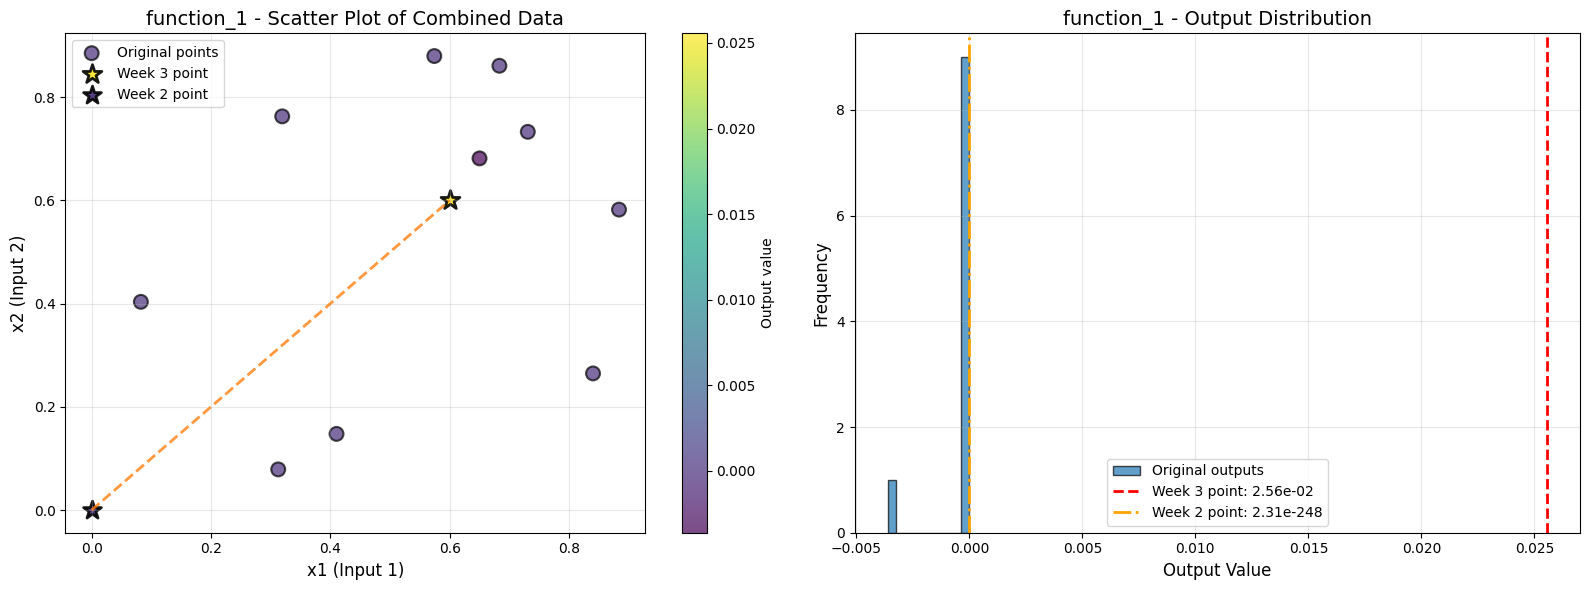


Combined inputs shape: (13, 2)
Combined outputs shape: (13,)


In [27]:
# Function 1 - Visualization using utility function
function_name = 'function_1'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']

# Visualize: show both Week 2 and Week 3 points with a connecting line
plot_2d_scatter_with_distribution(
    original_inputs, original_outputs, 
    week3_input, week3_output, 
    function_name,
    prior_input=week2_input,
    prior_output=week2_output,
    prior_point_label="Week 2 point",
    new_point_label="Week 3 point",
    connect_points=True,
    connect_color="tab:orange"
)

# Print combined data info
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1)
])
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output])
])
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 1 - LOGISTIC REGRESSION

**📓 See detailed analysis in:** [`function1_logistic_regression.ipynb`](./function1_logistic_regression.ipynb)

This dedicated notebook contains:
- **Hyperparameter tuning** across 180+ configurations
- **Model selection** based on MSE, accuracy, and log loss
- **Decision boundary visualization**
- **Next point prediction** using 3 different methods (grid search, random search, optimization)
- Finding the point **closest to the decision boundary** for maximum information gain

The analysis includes full visualizations and saves the recommended next point for evaluation.


---

*Logistic regression analysis moved to dedicated notebook above*


In [28]:
# Removed - see function1_logistic_regression.ipynb
pass


In [29]:
# Removed - see function1_logistic_regression.ipynb
pass


In [30]:
# Removed - see function1_logistic_regression.ipynb
pass


In [31]:
# Removed - see function1_logistic_regression.ipynb
pass


### FUNCTION 2 - COMBINED DATA AND VISUALISATION


In [32]:
# Function 2 - Combine original data with week 1, week 2, and week 3 data
# NOTE: Make sure you've run cells 4, 6, 8, and 10 first to load the data!

# Check if required data is loaded
required_vars = ['initial_data', 'week1_data', 'week2_data', 'week3_data']
missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise NameError(
        f"Missing required variables: {missing_vars}. "
        f"Please run the data loading cells first: "
        f"Cell 4 (initial_data), Cell 6 (week1_data), Cell 8 (week2_data), Cell 10 (week3_data)"
    )

function_name = 'function_2'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']

# Get week 2 new input and output
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Get week 3 new input and output
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']

# Combine inputs: original + week 1 + week 2 + week 3
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1)
])

# Combine outputs: original + week 1 + week 2 + week 3
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output])
])

print("=" * 60)
print(f"FUNCTION 2 - COMBINED DATA (Week 1 + Week 2 + Week 3)")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nWeek 1 input: {week1_input}")
print(f"Week 2 input: {week2_input}")
print(f"Week 3 input: {week3_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nWeek 1 output: {week1_output}")
print(f"Week 2 output: {week2_output}")
print(f"Week 3 output: {week3_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 2 - COMBINED DATA (Week 1 + Week 2 + Week 3)

Original inputs shape: (10, 2)
Original inputs:
[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]]

Week 1 input: [0.65 0.5 ]
Week 2 input: [0.839041 1.      ]
Week 3 input: [0.763745 0.848033]

Combined inputs shape: (13, 2)
Combined inputs:
[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.65       0.5       ]
 [0.839041   1.        ]
 [0.763745   0.848033  ]]

------------------------------------------------------------

Original outputs shape: (10,)
Original outputs:
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.0

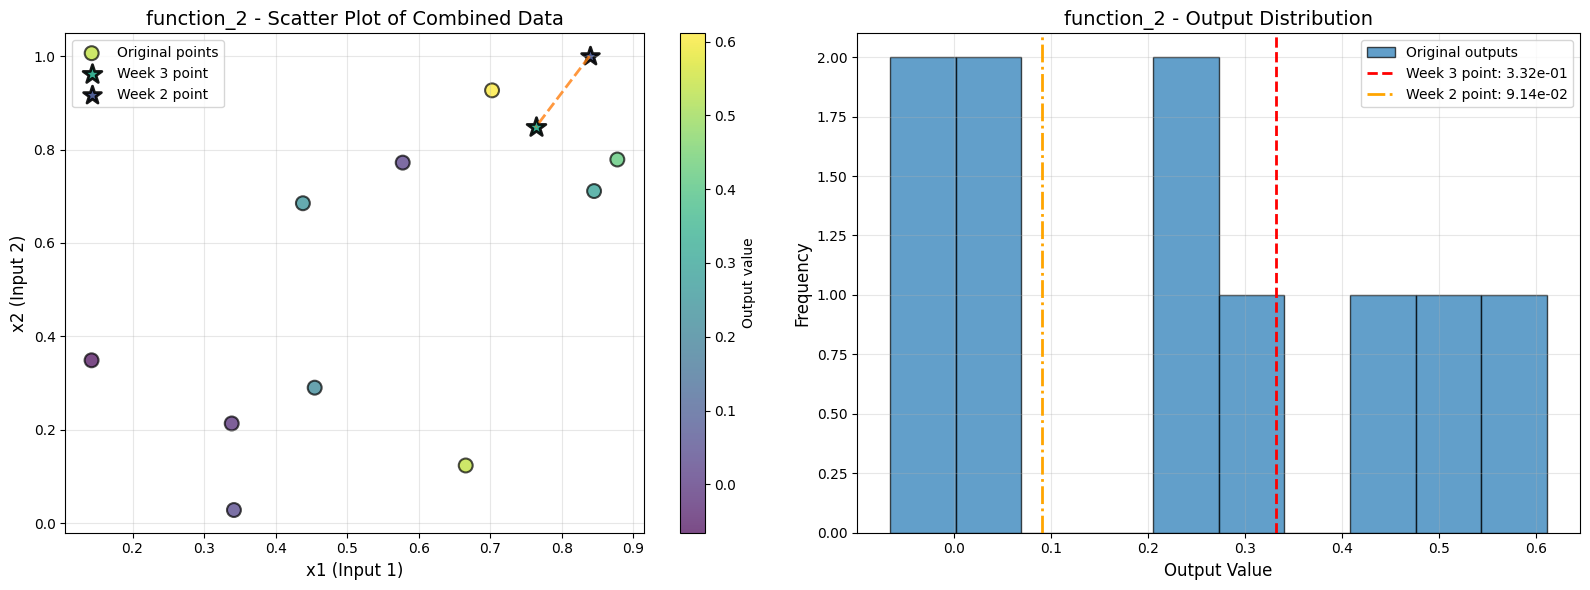


Combined inputs shape: (13, 2)
Combined outputs shape: (13,)


In [33]:
# Function 2 - Visualization using utility function
function_name = 'function_2'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']

# Visualize: show both Week 2 and Week 3 points with a connecting line
plot_2d_scatter_with_distribution(
    original_inputs, original_outputs, 
    week3_input, week3_output, 
    function_name,
    prior_input=week2_input,
    prior_output=week2_output,
    prior_point_label="Week 2 point",
    new_point_label="Week 3 point",
    connect_points=True,
    connect_color="tab:orange"
)

# Print combined data info
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1)
])
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output])
])
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 3 - COMBINED DATA AND VISUALISATION


In [34]:
# Function 3 - Combine original data with week 1, week 2, and week 3 data
function_name = 'function_3'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']

# Get week 2 new input and output
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Get week 3 new input and output
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']

# Combine inputs: original + week 1 + week 2 + week 3
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1)
])

# Combine outputs: original + week 1 + week 2 + week 3
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output])
])

print("=" * 60)
print(f"FUNCTION 3 - COMBINED DATA (Week 1 + Week 2 + Week 3)")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nWeek 1 input: {week1_input}")
print(f"Week 2 input: {week2_input}")
print(f"Week 3 input: {week3_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nWeek 1 output: {week1_output}")
print(f"Week 2 output: {week2_output}")
print(f"Week 3 output: {week3_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 3 - COMBINED DATA (Week 1 + Week 2 + Week 3)

Original inputs shape: (15, 3)
Original inputs:
[[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.43999062 0.99088187]
 [0.64550284 0.39714294 0.91977134]
 [0.74691195 0.28419631 0.22629985]
 [0.17047699 0.6970324  0.14916943]
 [0.22054934 0.29782524 0.34355534]
 [0.66601366 0.67198515 0.2462953 ]
 [0.04680895 0.23136024 0.77061759]
 [0.60009728 0.72513573 0.06608864]
 [0.96599485 0.86111969 0.56682913]]

Week 1 input: [0.466753 0.990442 0.996265]
Week 2 input: [1.      0.      0.75783]
Week 3 input: [1. 1. 0.]

Combined inputs shape: (18, 3)
Combined inputs:
[[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.941

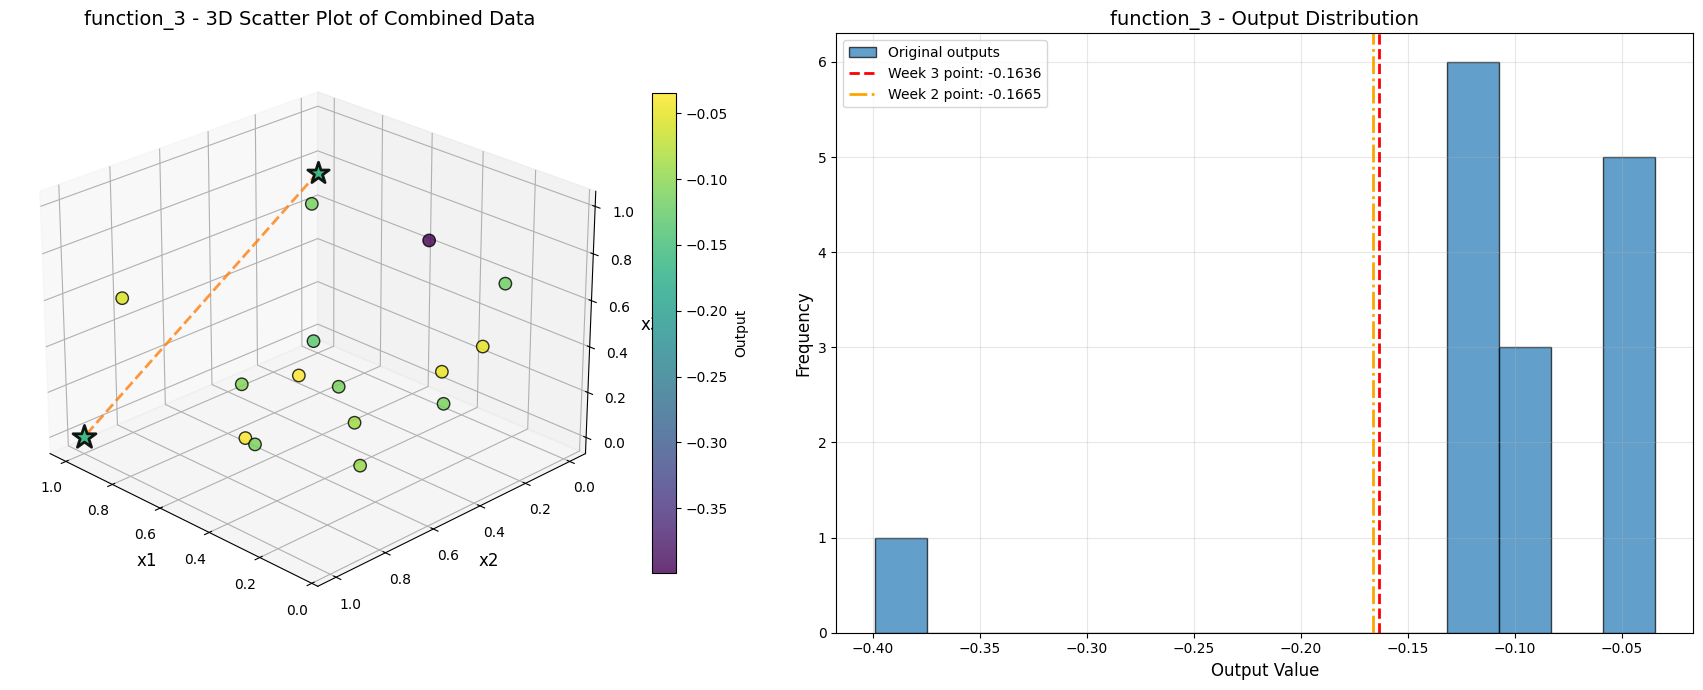


Combined inputs shape: (18, 3)
Combined outputs shape: (18,)


In [35]:
# Function 3 - Visualization using utility function
function_name = 'function_3'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']

# Visualize: show both Week 2 and Week 3 points with a connecting line
plot_3d_scatter_with_distribution(
    original_inputs, original_outputs, 
    week3_input, week3_output, 
    function_name,
    prior_input=week2_input,
    prior_output=week2_output,
    prior_point_label="Week 2 point",
    new_point_label="Week 3 point",
    connect_points=True,
    connect_color="tab:orange"
)

# Print combined data info
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1)
])
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output])
])
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 4 - COMBINED DATA AND VISUALISATION


In [36]:
# Function 4 - Combine original data with week 1, week 2, and week 3 data
function_name = 'function_4'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']

# Get week 2 new input and output
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Get week 3 new input and output
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']

# Combine inputs: original + week 1 + week 2 + week 3
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1)
])

# Combine outputs: original + week 1 + week 2 + week 3
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output])
])

print("=" * 60)
print(f"FUNCTION 4 - COMBINED DATA (Week 1 + Week 2 + Week 3)")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nWeek 1 input: {week1_input}")
print(f"Week 2 input: {week2_input}")
print(f"Week 3 input: {week3_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nWeek 1 output: {week1_output}")
print(f"Week 2 output: {week2_output}")
print(f"Week 3 output: {week3_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 4 - COMBINED DATA (Week 1 + Week 2 + Week 3)

Original inputs shape: (30, 4)
Original inputs:
[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.

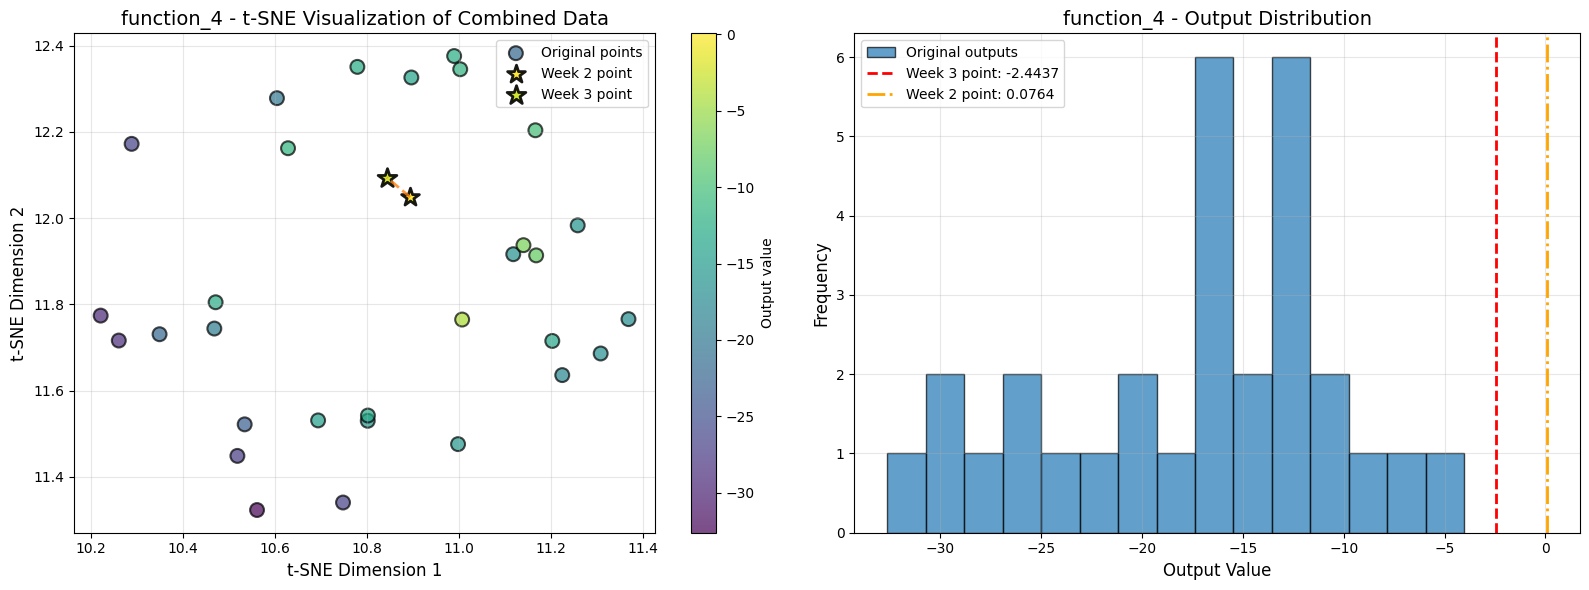


Combined inputs shape: (33, 4)
Combined outputs shape: (33,)


In [37]:
# Function 4 - Visualization using utility function
function_name = 'function_4'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']

# Visualize: show both Week 2 and Week 3 points with a connecting line
plot_tsne_with_distribution(
    original_inputs, original_outputs, 
    week3_input, week3_output, 
    function_name,
    prior_input=week2_input,
    prior_output=week2_output,
    prior_point_label="Week 2 point",
    new_point_label="Week 3 point",
    connect_points=True,
    connect_color="tab:orange",
    random_state=TSNE_RANDOM_STATE
)

# Print combined data info
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1)
])
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output])
])
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 5 - COMBINED DATA AND VISUALISATION


In [38]:
# Function 5 - Combine original data with week 1, week 2, and week 3 data
function_name = 'function_5'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']

# Get week 2 new input and output
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Get week 3 new input and output
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']

# Combine inputs: original + week 1 + week 2 + week 3
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1)
])

# Combine outputs: original + week 1 + week 2 + week 3
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output])
])

print("=" * 60)
print(f"FUNCTION 5 - COMBINED DATA (Week 1 + Week 2 + Week 3)")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nWeek 1 input: {week1_input}")
print(f"Week 2 input: {week2_input}")
print(f"Week 3 input: {week3_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nWeek 1 output: {week1_output}")
print(f"Week 2 output: {week2_output}")
print(f"Week 3 output: {week3_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 5 - COMBINED DATA (Week 1 + Week 2 + Week 3)

Original inputs shape: (20, 4)
Original inputs:
[[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.

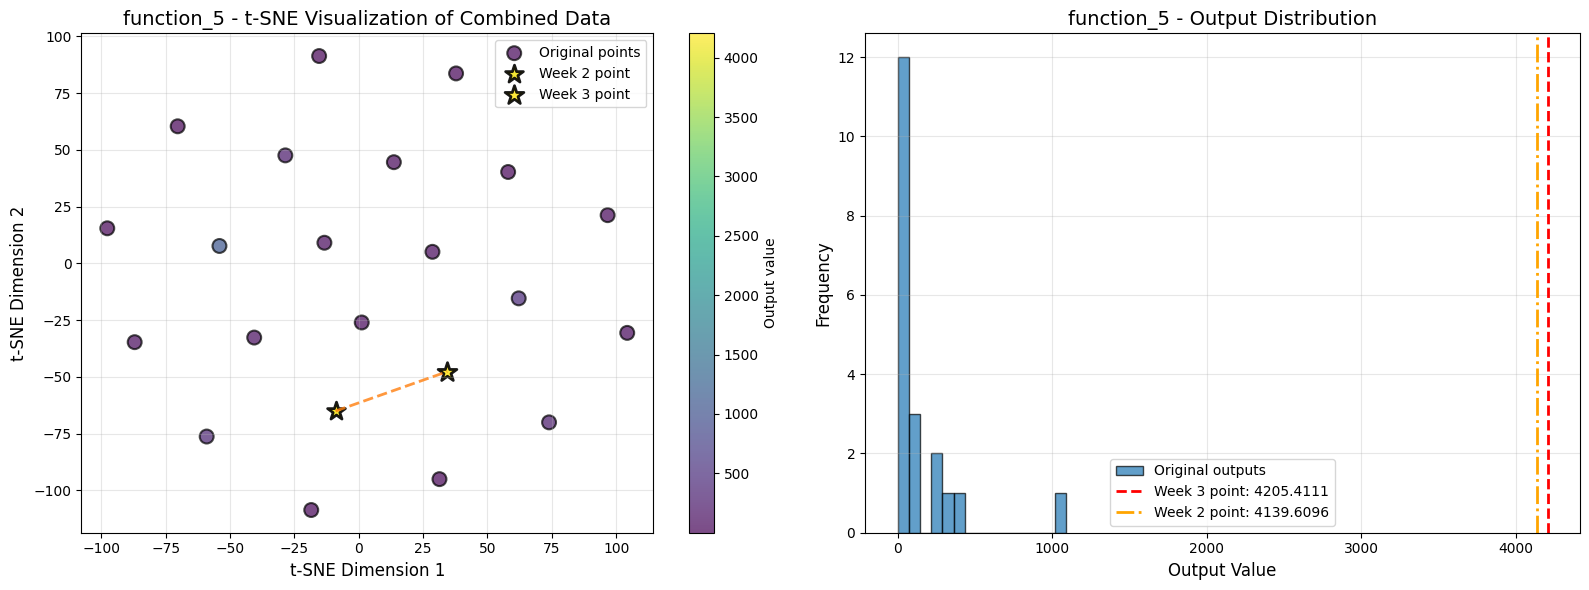


Combined inputs shape: (23, 4)
Combined outputs shape: (23,)


In [39]:
# Function 5 - Visualization using utility function
function_name = 'function_5'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']

# Visualize: show both Week 2 and Week 3 points with a connecting line
plot_tsne_with_distribution(
    original_inputs, original_outputs, 
    week3_input, week3_output, 
    function_name,
    prior_input=week2_input,
    prior_output=week2_output,
    prior_point_label="Week 2 point",
    new_point_label="Week 3 point",
    connect_points=True,
    connect_color="tab:orange",
    random_state=TSNE_RANDOM_STATE
)

# Print combined data info
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1)
])
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output])
])
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 6 - COMBINED DATA AND VISUALISATION


In [40]:
# Function 6 - Combine original data with week 1, week 2, and week 3 data
function_name = 'function_6'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']

# Get week 2 new input and output
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Get week 3 new input and output
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']

# Combine inputs: original + week 1 + week 2 + week 3
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1)
])

# Combine outputs: original + week 1 + week 2 + week 3
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output])
])

print("=" * 60)
print(f"FUNCTION 6 - COMBINED DATA (Week 1 + Week 2 + Week 3)")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nWeek 1 input: {week1_input}")
print(f"Week 2 input: {week2_input}")
print(f"Week 3 input: {week3_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nWeek 1 output: {week1_output}")
print(f"Week 2 output: {week2_output}")
print(f"Week 3 output: {week3_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 6 - COMBINED DATA (Week 1 + Week 2 + Week 3)

Original inputs shape: (20, 5)
Original inputs:
[[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6

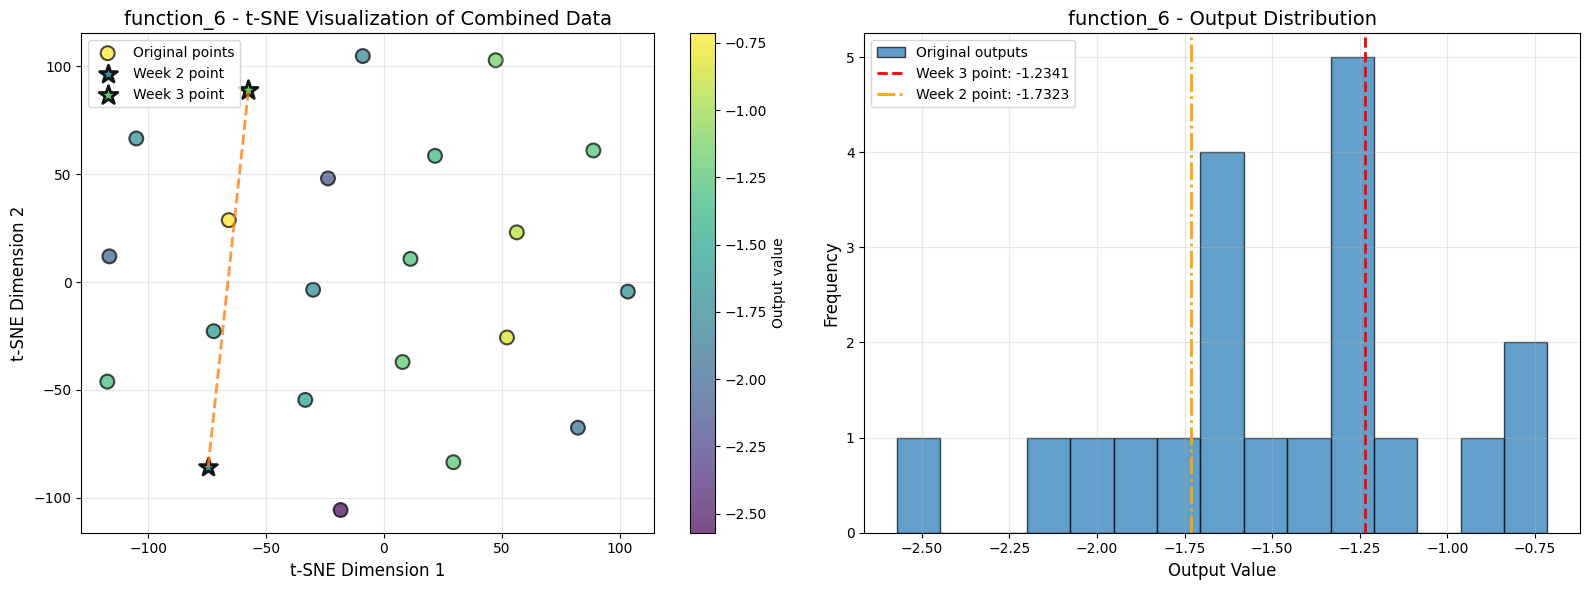


Combined inputs shape: (23, 5)
Combined outputs shape: (23,)


In [41]:
# Function 6 - Visualization using utility function
function_name = 'function_6'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']

# Visualize: show both Week 2 and Week 3 points with a connecting line
plot_tsne_with_distribution(
    original_inputs, original_outputs, 
    week3_input, week3_output, 
    function_name,
    prior_input=week2_input,
    prior_output=week2_output,
    prior_point_label="Week 2 point",
    new_point_label="Week 3 point",
    connect_points=True,
    connect_color="tab:orange",
    random_state=TSNE_RANDOM_STATE
)

# Print combined data info
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1)
])
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output])
])
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 7 - COMBINED DATA AND VISUALISATION


In [42]:
# Function 7 - Combine original data with week 1, week 2, and week 3 data
function_name = 'function_7'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']

# Get week 2 new input and output
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Get week 3 new input and output
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']

# Combine inputs: original + week 1 + week 2 + week 3
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1)
])

# Combine outputs: original + week 1 + week 2 + week 3
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output])
])

print("=" * 60)
print(f"FUNCTION 7 - COMBINED DATA (Week 1 + Week 2 + Week 3)")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nWeek 1 input: {week1_input}")
print(f"Week 2 input: {week2_input}")
print(f"Week 3 input: {week3_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nWeek 1 output: {week1_output}")
print(f"Week 2 output: {week2_output}")
print(f"Week 3 output: {week3_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 7 - COMBINED DATA (Week 1 + Week 2 + Week 3)

Original inputs shape: (30, 6)
Original inputs:
[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]


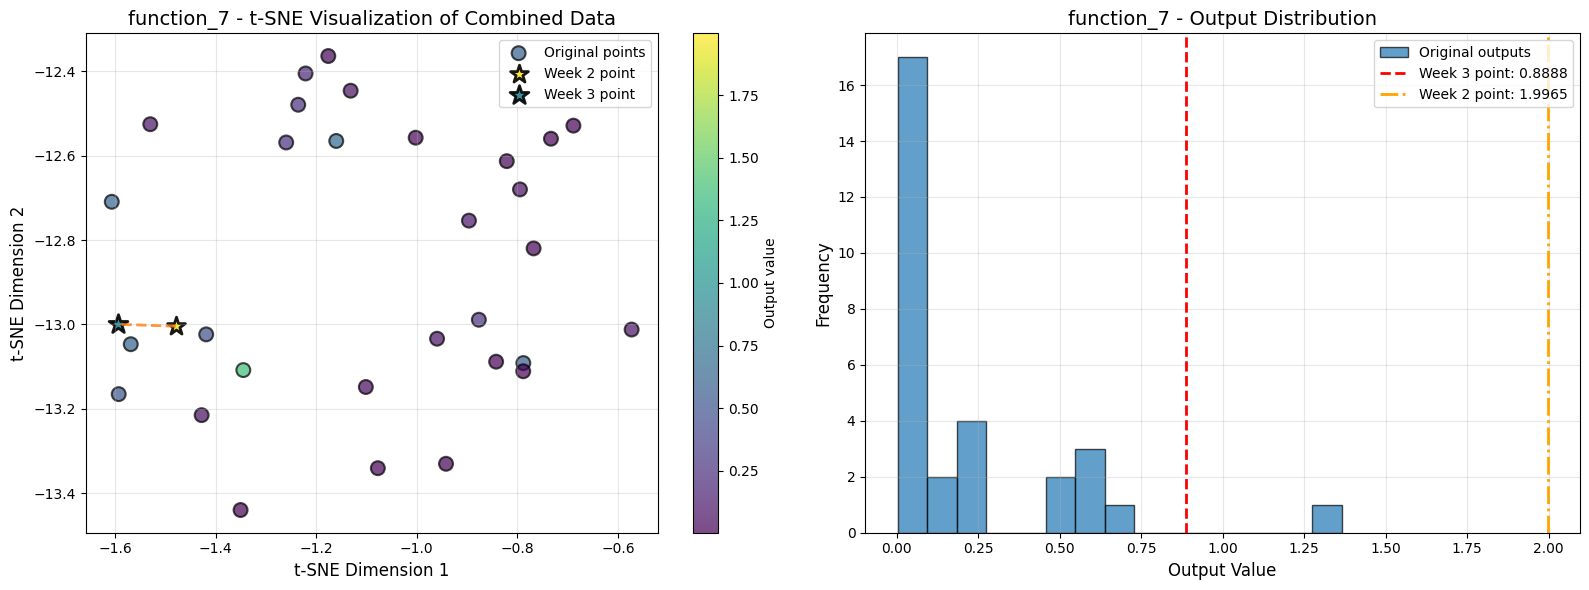


Combined inputs shape: (33, 6)
Combined outputs shape: (33,)


In [43]:
# Function 7 - Visualization using utility function
function_name = 'function_7'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']

# Visualize: show both Week 2 and Week 3 points with a connecting line
plot_tsne_with_distribution(
    original_inputs, original_outputs, 
    week3_input, week3_output, 
    function_name,
    prior_input=week2_input,
    prior_output=week2_output,
    prior_point_label="Week 2 point",
    new_point_label="Week 3 point",
    connect_points=True,
    connect_color="tab:orange",
    random_state=TSNE_RANDOM_STATE
)

# Print combined data info
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1)
])
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output])
])
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 8 - COMBINED DATA AND VISUALISATION


In [44]:
# Function 8 - Combine original data with week 1, week 2, and week 3 data
function_name = 'function_8'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']

# Get week 2 new input and output
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Get week 3 new input and output
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']

# Combine inputs: original + week 1 + week 2 + week 3
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1)
])

# Combine outputs: original + week 1 + week 2 + week 3
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output])
])

print("=" * 60)
print(f"FUNCTION 8 - COMBINED DATA (Week 1 + Week 2 + Week 3)")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nWeek 1 input: {week1_input}")
print(f"Week 2 input: {week2_input}")
print(f"Week 3 input: {week3_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nWeek 1 output: {week1_output}")
print(f"Week 2 output: {week2_output}")
print(f"Week 3 output: {week3_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 8 - COMBINED DATA (Week 1 + Week 2 + Week 3)

Original inputs shape: (40, 8)
Original inputs:
[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.2

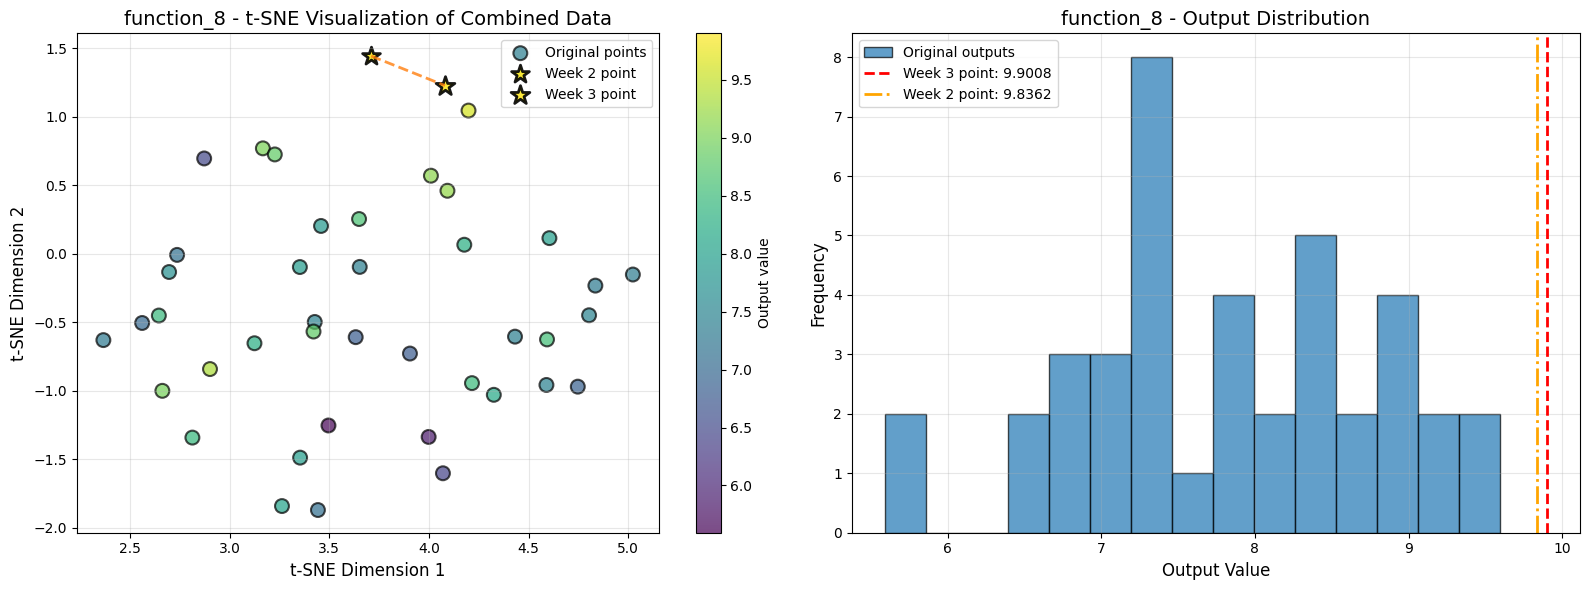


Combined inputs shape: (43, 8)
Combined outputs shape: (43,)


In [45]:
# Function 8 - Visualization using utility function
function_name = 'function_8'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']

# Visualize: show both Week 2 and Week 3 points with a connecting line
plot_tsne_with_distribution(
    original_inputs, original_outputs, 
    week3_input, week3_output, 
    function_name,
    prior_input=week2_input,
    prior_output=week2_output,
    prior_point_label="Week 2 point",
    new_point_label="Week 3 point",
    connect_points=True,
    connect_color="tab:orange",
    random_state=TSNE_RANDOM_STATE
)

# Print combined data info
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1)
])
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output])
])
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### BAYESIAN OPTIMIZATION - GP + UCB


In [46]:
# Import the Bayesian Optimization module
from bayesian_optimization import SimpleBayesianOptimization


In [47]:
# Prepare data for Bayesian Optimization
# We'll use the combined data (original + week 1 + week 2 + week 3) as our starting observations

bo_results = {}

for function_num in range(1, 9):
    function_name = f'function_{function_num}'

    # Get combined data
    original_inputs = initial_data[function_name]['inputs']
    original_outputs = initial_data[function_name]['outputs']
    week1_input = week1_data[function_name]['input']
    week1_output = week1_data[function_name]['output']
    week2_input = week2_data[function_name]['input']
    week2_output = week2_data[function_name]['output']
    week3_input = week3_data[function_name]['input']
    week3_output = week3_data[function_name]['output']

    # Combine all observed data
    X_observed = np.vstack([
        original_inputs, 
        week1_input.reshape(1, -1),
        week2_input.reshape(1, -1),
        week3_input.reshape(1, -1)
    ])
    y_observed = np.concatenate([
        original_outputs, 
        np.array([week1_output]),
        np.array([week2_output]),
        np.array([week3_output])
    ])

    # Define bounds (all functions have inputs in [0, 1])
    n_dims = X_observed.shape[1]
    bounds = [[0.0, 1.0]] * n_dims

    # Create BO object
    bo = SimpleBayesianOptimization(bounds=bounds, n_initial=0, random_state=42)

    # Fit GP to observed data
    bo.fit(X_observed, y_observed)

    # Store results
    bo_results[function_name] = {
        'bo': bo,
        'X_observed': X_observed,
        'y_observed': y_observed,
        'n_dims': n_dims,
        'week1_input': week1_input,
        'week1_output': week1_output,
        'week2_input': week2_input,
        'week2_output': week2_output,
        'week3_input': week3_input,
        'week3_output': week3_output,
    }

    print(f"{function_name}: Fitted GP to {len(X_observed)} observations ({n_dims}D)")


function_1: Fitted GP to 13 observations (2D)
function_2: Fitted GP to 13 observations (2D)
function_3: Fitted GP to 18 observations (3D)
function_4: Fitted GP to 33 observations (4D)
function_5: Fitted GP to 23 observations (4D)


/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


function_6: Fitted GP to 23 observations (5D)
function_7: Fitted GP to 33 observations (6D)
function_8: Fitted GP to 43 observations (8D)


In [48]:
# Suggest next points for all functions using UCB
next_points_bo = {}
ucb_values = {}

print("=" * 60)
print("BAYESIAN OPTIMIZATION - NEXT POINT SUGGESTIONS")
print("=" * 60)

for function_num in range(1, 9):
    function_name = f'function_{function_num}'
    bo = bo_results[function_name]['bo']
    
    # Suggest next point using UCB
    next_point = bo.suggest_next_point(beta=2.0)
    
    # Get UCB value at this point
    ucb_value = bo.acquisition_ucb(next_point.reshape(1, -1), beta=2.0)[0]
    
    next_points_bo[function_name] = next_point
    ucb_values[function_name] = ucb_value
    
    # Format point for display
    formatted_point = '-'.join([f'{x:.6f}' for x in next_point])
    
    print(f"\n{function_name}:")
    print(f"  Suggested point: {formatted_point}")
    print(f"  UCB value: {ucb_value:.6f}")

print("=" * 60)


BAYESIAN OPTIMIZATION - NEXT POINT SUGGESTIONS

function_1:
  Suggested point: 0.681188-0.492588
  UCB value: 0.072146

function_2:
  Suggested point: 0.638474-0.995250
  UCB value: 0.891855

function_3:
  Suggested point: 0.460275-0.000000-0.633497
  UCB value: 0.303356

function_4:
  Suggested point: 0.361687-0.402832-0.449644-0.441510
  UCB value: 1.234372

function_5:
  Suggested point: 0.222727-0.846708-0.876164-0.878111
  UCB value: 1090.715814

function_6:
  Suggested point: 0.000000-1.000000-0.000000-1.000000-0.000000
  UCB value: 0.916730

function_7:
  Suggested point: 0.075432-0.296150-0.417386-0.217001-0.306418-0.646435
  UCB value: 2.343395

function_8:
  Suggested point: 0.118298-0.308389-0.000000-0.262773-0.521512-0.648236-0.098503-0.320260
  UCB value: 10.337042


### SANITY CHECK - Visualize GP Predictions and UCB


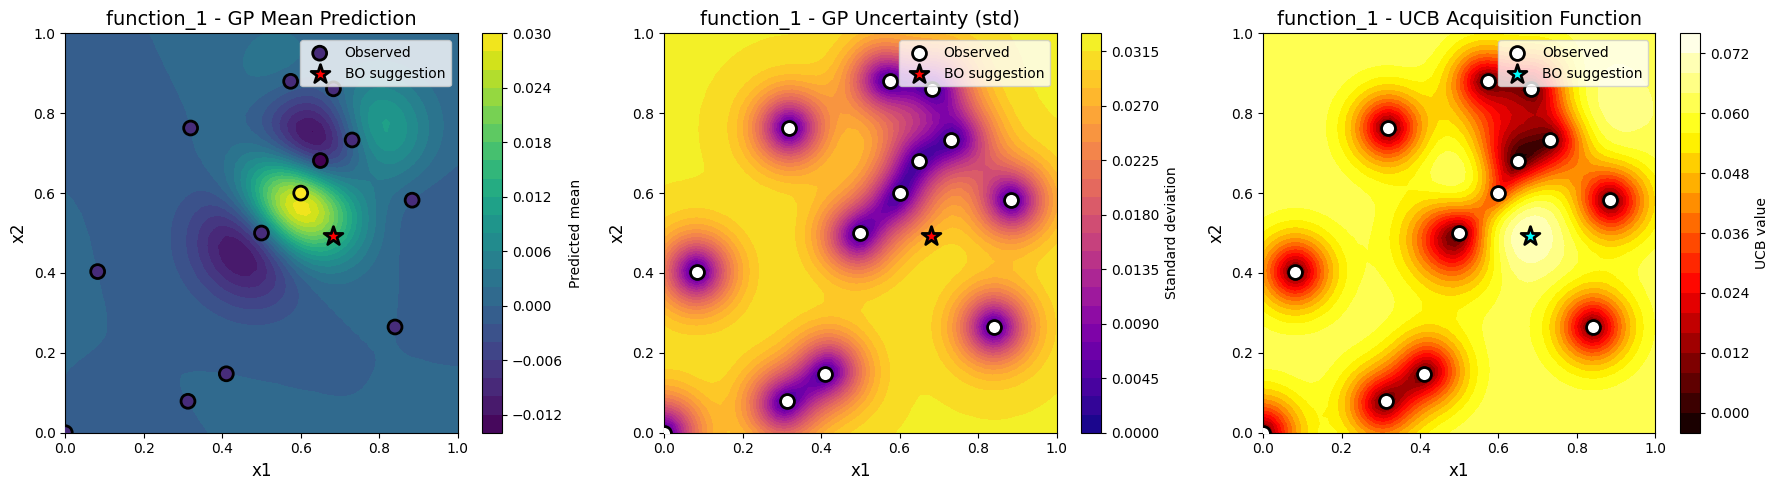


Function 1 BO Summary:
  Observed points: 13
  Best observed value: 0.025559
  Suggested next point: [0.681188, 0.492588]
  UCB value at suggestion: 0.072146


In [49]:
# Sanity check: Visualize GP predictions for Function 1 (2D - easy to visualize)
function_name = 'function_1'
bo = bo_results[function_name]['bo']
X_obs = bo_results[function_name]['X_observed']
y_obs = bo_results[function_name]['y_observed']
next_point = next_points_bo[function_name]

# Use utility function for BO visualization
plot_bo_visualization_2d(bo, X_obs, y_obs, next_point, function_name)

print(f"\nFunction 1 BO Summary:")
print(f"  Observed points: {len(X_obs)}")
print(f"  Best observed value: {y_obs.max():.6f}")
print(f"  Suggested next point: [{next_point[0]:.6f}, {next_point[1]:.6f}]")
print(f"  UCB value at suggestion: {ucb_values[function_name]:.6f}")


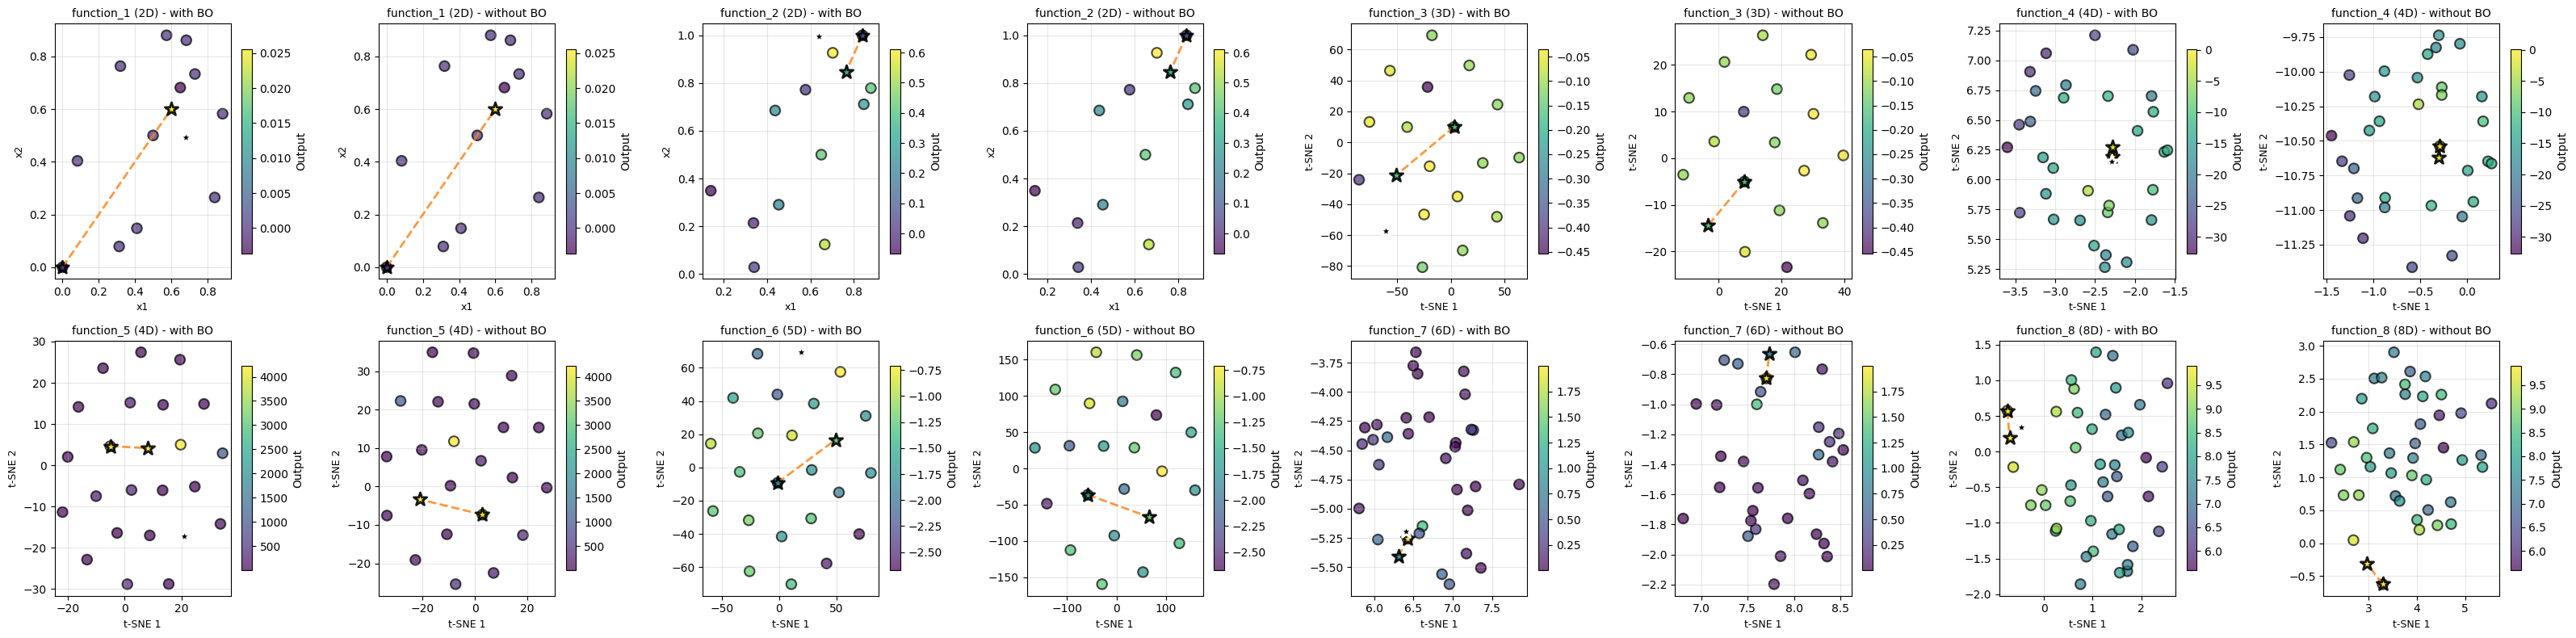


Summary:
  Left plots: Visualization WITH BO point included in t-SNE/scatter
  Right plots: Visualization WITHOUT BO point (matches individual plot style)
  Orange dashed line: Week 2 -> Week 3
  Black stars: BO-suggested next points (only visible in left plots)


In [50]:
# Sanity check: Compare BO suggestions with observed data for all functions
# Left plot shows visualization WITH BO point, right plot shows WITHOUT BO point (matching individual plots)

# Reload the module to ensure we have the latest version
import importlib
import data_utils
importlib.reload(data_utils)
from data_utils import plot_function_summary_subplot

fig, axes = plt.subplots(2, 8, figsize=(32, 8))
axes = axes.flatten()

for idx, function_num in enumerate(range(1, 9)):
    function_name = f'function_{function_num}'

    # Get data
    original_inputs = initial_data[function_name]['inputs']
    original_outputs = initial_data[function_name]['outputs']
    week1_input = bo_results[function_name]['week1_input']
    week1_output = bo_results[function_name]['week1_output']
    week2_input = bo_results[function_name]['week2_input']
    week2_output = bo_results[function_name]['week2_output']
    week3_input = bo_results[function_name]['week3_input']
    week3_output = bo_results[function_name]['week3_output']
    bo_next_point = next_points_bo[function_name]
    n_dims = bo_results[function_name]['n_dims']

    # Treat week 2 as prior, week 3 as latest
    inputs_with_week2 = np.vstack([
        original_inputs,
        week1_input.reshape(1, -1),
        week2_input.reshape(1, -1)
    ])
    outputs_with_week2 = np.concatenate([
        original_outputs,
        np.array([week1_output]),
        np.array([week2_output])
    ])

    # Get left and right axes for this function (2 subplots per function)
    ax_left = axes[idx * 2]
    ax_right = axes[idx * 2 + 1]

    # Use utility function to plot
    # Left: with BO point, Right: without BO point (matches individual plot style)
    plot_function_summary_subplot(
        ax_left, ax_right,
        inputs_with_week2, outputs_with_week2,
        week3_input, week3_output,
        bo_next_point,
        function_name, n_dims,
        random_state=TSNE_RANDOM_STATE,
        week1_input=week2_input,
        week1_output=week2_output,
        prior_point_label="Week 2 point",
        new_point_label="Week 3 point"
    )

plt.tight_layout()
plt.show()

print("\nSummary:")
print("  Left plots: Visualization WITH BO point included in t-SNE/scatter")
print("  Right plots: Visualization WITHOUT BO point (matches individual plot style)")
print("  Orange dashed line: Week 2 -> Week 3")
print("  Black stars: BO-suggested next points (only visible in left plots)")


In [ ]:
# Print all BO suggestions in format ready for submission
# Note: Function 1 uses result from logistic regression notebook if available

import json
import os

print("=" * 60)
print("BAYESIAN OPTIMIZATION - NEXT POINTS FOR SUBMISSION")
print("=" * 60)
print("\nFormat: x1-x2-x3-... (one point per function)")
print()

# Check if Function 1 logistic regression result exists
function1_json_path = 'function1_next_point.json'
function1_uses_lr = False

if os.path.exists(function1_json_path):
    try:
        with open(function1_json_path, 'r') as f:
            function1_lr_result = json.load(f)
            function1_uses_lr = True
            print(f"✓ Using Function 1 result from logistic regression notebook")
    except:
        pass

for function_num in range(1, 9):
    function_name = f'function_{function_num}'
    
    # Use logistic regression result for function_1 if available
    if function_num == 1 and function1_uses_lr:
        formatted_point = function1_lr_result['formatted']
        print(f"{function_name}: {formatted_point}  # (from logistic regression)")
    else:
        next_point = next_points_bo[function_name]
        formatted_point = '-'.join([f'{x:.6f}' for x in next_point])
        print(f"{function_name}: {formatted_point}")

print()
print("=" * 60)


BAYESIAN OPTIMIZATION - NEXT POINTS FOR SUBMISSION

Format: x1-x2-x3-... (one point per function)

function_1: 0.681188-0.492588
function_2: 0.638474-0.995250
function_3: 0.460275-0.000000-0.633497
function_4: 0.361687-0.402832-0.449644-0.441510
function_5: 0.222727-0.846708-0.876164-0.878111
function_6: 0.000000-1.000000-0.000000-1.000000-0.000000
function_7: 0.075432-0.296150-0.417386-0.217001-0.306418-0.646435
function_8: 0.118298-0.308389-0.000000-0.262773-0.521512-0.648236-0.098503-0.320260

